In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sagarupsc/day1video/14931663_1080_1920_60fps.mp4
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolo26x_full1920_nmsFalse_part008.npz
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolov8x_full1920_part003.npz
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolo26x_full1920_nmsTrue_part005.npz
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolo26x_tiles640_1280_part000.npz
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolo26x_tiles640_1280_part012.npz
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolo26x_full1920_nmsTrue_part013.npz
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolo26x_full1920_nmsFalse_part010.npz
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolov8x_full1920_part011.npz
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolo26x_tiles640_1280_part004.npz
/kaggle/input/datasets/sagarupsc/e003-detections-all/yolo26x_full1920_nmsFalse_part012.npz
/kaggle/input/datasets/sagarupsc/e003-detections-a

# E003b — Camera registration with crowd masks

**The problem in simple words:** we want to measure how fast people move. But if the camera itself moves a little (a shake or a slow drift), every pixel appears to move, and we would wrongly read that as crowd motion. So first we must work out how the camera moved between frames and cancel it.

**How we do it:** we find easy-to-track spots in the picture (corners, edges) in two frames and see how they shifted. If all the tracked spots are on the static background, their shift tells us the camera motion exactly. But in a crowd, many of the spots are on *people*, who are moving, and they fool the estimate. Earlier tests showed that without a mask the error grew to about 94 pixels, and with the crowd masked out it dropped to about 8 pixels.

**What this notebook does:**
1. Loads the person boxes we saved in E003 and builds a *crowd mask*, the areas where people are, which the camera step must ignore.
2. Checks how well each candidate mask covers the people we labelled by hand.
3. Estimates the camera motion over all 1303 frames, using only the background.
4. Checks the estimate for slow drift.

**What comes out:** one file with the camera motion for every frame, used by all later steps (density, flow, pressure).

## Cell 2 — Load the project code, the saved boxes and the video

**In simple words:** this cell downloads our project code from GitHub, then finds the two things we attached to this notebook: the saved person boxes from E003 (four detector settings, all 1303 frames) and the video. It checks that everything is complete before we do anything else.

**What you should see:**
- The paths of the boxes dataset and the video.
- For each of the four detector runs: 1303 frames, and the total number of boxes.
- The two candidate mask sources that E003 recorded.

**If something is missing:** the message says exactly which input to add (Add Input, top right).

In [4]:
# ===== Cell 2: clone repo, locate the E003 detections (dataset or zip) and the video, load and verify =====
import os, sys, glob, json, subprocess, zipfile
from pathlib import Path
import numpy as np
import cv2

REPO_URL = "https://github.com/SagarInspires/crowd-intelligence.git"
REPO_DIR = Path("/kaggle/working/crowd-intelligence")
OUT5 = Path("/kaggle/working/outputs/registration")
OUT5.mkdir(parents=True, exist_ok=True)

def sync_repo():
    """Clone the repo if absent, otherwise pull; put it on sys.path so `src.*` imports work."""
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--rebase"], check=True)
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))

def find_one(pattern, what):
    """Return the single file matching a glob pattern under /kaggle/input; stop with a clear message otherwise."""
    hits = sorted(glob.glob(pattern, recursive=True))
    assert len(hits) == 1, f"{what}: expected exactly 1 match for {pattern}, found {len(hits)}: {hits} " \
                           f"(add the missing dataset with 'Add Input')"
    return Path(hits[0])

def locate_detections():
    """Folder that holds E003_decisions.json. If the dataset kept the upload as one zip, extract it first."""
    hits = glob.glob("/kaggle/input/**/E003_decisions.json", recursive=True)
    if len(hits) == 1:
        return Path(hits[0]).parent
    zips = glob.glob("/kaggle/input/**/e003_detections_all.zip", recursive=True)
    assert len(zips) == 1, ("could not find the E003 detections: no E003_decisions.json and no "
                            "e003_detections_all.zip under /kaggle/input (add the dataset with 'Add Input')")
    dest = Path("/kaggle/working/e003_detections"); dest.mkdir(exist_ok=True)
    with zipfile.ZipFile(zips[0]) as z:
        z.extractall(dest)
    return dest

def load_run(tag, out_dir):
    """Load all shards of one detector run -> dict(frame_ids, counts, boxes, scores, secs)."""
    parts = sorted(Path(out_dir).glob(f"{tag}_part*.npz"))
    assert parts, f"no shards for {tag} in {out_dir}"
    z = [np.load(p) for p in parts]
    return {k: np.concatenate([a[k] for a in z]) for k in ("frame_ids", "counts", "boxes", "scores", "secs")}

def boxes_for(run, fid):
    """Boxes and scores of one video frame from a saved run (frame_ids are 0..N-1 in order)."""
    off = np.concatenate([[0], np.cumsum(run["counts"])])
    i = int(np.searchsorted(run["frame_ids"], fid))
    assert run["frame_ids"][i] == fid
    return run["boxes"][off[i]:off[i + 1]], run["scores"][off[i]:off[i + 1]]

sync_repo()
DET_DIR = locate_detections()
VIDEO = find_one("/kaggle/input/**/*14931663*.mp4", "video")
decisions = json.loads((DET_DIR / "E003_decisions.json").read_text())

TAGS = ["yolov8x_full1920", "yolo26x_full1920_nmsTrue", "yolo26x_full1920_nmsFalse", "yolo26x_tiles640_1280"]
runs = {t: load_run(t, DET_DIR) for t in TAGS}

cap = cv2.VideoCapture(str(VIDEO))
N_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); FPS = cap.get(cv2.CAP_PROP_FPS)
W, H = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)); cap.release()

print("detections:", DET_DIR)
print("video     :", VIDEO, f"| {N_FRAMES} frames, {W}x{H}, {FPS:.2f} fps")
for t, r in runs.items():
    assert np.array_equal(r["frame_ids"], np.arange(N_FRAMES)), f"{t}: frames are not 0..{N_FRAMES - 1}"
    print(f"{t:28s} {len(r['frame_ids'])} frames | {len(r['scores']):,} boxes above the 0.001 floor")
print("\nmask candidates recorded in E003:")
for c in decisions["candidates"]:
    print(f"  {c['source']:28s} cutoff {c['cutoff']}  ({c['cost_s_per_frame']} s/frame)")

Cloning into '/kaggle/working/crowd-intelligence'...


detections: /kaggle/input/datasets/sagarupsc/e003-detections-all
video     : /kaggle/input/datasets/sagarupsc/day1video/14931663_1080_1920_60fps.mp4 | 1303 frames, 1080x1920, 59.94 fps
yolov8x_full1920             1303 frames | 1,383,611 boxes above the 0.001 floor
yolo26x_full1920_nmsTrue     1303 frames | 2,129,814 boxes above the 0.001 floor
yolo26x_full1920_nmsFalse    1303 frames | 2,025,251 boxes above the 0.001 floor
yolo26x_tiles640_1280        1303 frames | 3,577,993 boxes above the 0.001 floor

mask candidates recorded in E003:
  yolo26x_tiles640_1280        cutoff 0.016  (2.36 s/frame)
  yolo26x_full1920_nmsTrue     cutoff 0.011  (0.39 s/frame)


## Cell 3 — Build the crowd masks and check how good they are

**In simple words:** a crowd mask is a black-and-white picture: white where people are, black where the background is. The camera step will look for tracking spots only in the black area. A good mask hides all the people (so they cannot fool the camera estimate) while still leaving enough background to track.

**We build masks from the saved person boxes.** The two candidate sources are:
- the tiled YOLO26x boxes (best at finding far-away people, but slow to compute), and
- the full-frame YOLO26x boxes with NMS (nearly as good, six times cheaper).

**We try different settings:** a lower confidence cutoff (accept more uncertain boxes, so fewer people are missed) and a small "grow" of each box (fills the gaps between neighbours).

**Two measurements decide, on the 15 frames where we clicked every head:**
1. **Head coverage:** what share of the labelled heads is inside the mask. Higher is better, because an uncovered person can fool the camera estimate.
2. **Background left:** what share of the picture is not masked. This must stay large enough to find tracking spots.

**How to read it:** we want high coverage with a reasonable amount of background left. If pushing coverage up makes the background almost disappear, that setting is too aggressive.

In [5]:
#black for background pixels (pixel movement not detected between two frames)
#white for foreground (moving pixels)
# ===== Cell 3: crowd masks from the E003 boxes, scored on the labelled heads =====
import pandas as pd
from src.data.via import load_ground_truth

pts, ign, _ = load_ground_truth(REPO_DIR / "data/your_video")
ids = sorted(int(i) for i in pts.frame_id.unique())          # the 15 labelled frames
far_y = H / 2
SC = 0.25                                                     # masks are built at quarter resolution (fast)

def build_mask(boxes, scores, cutoff, shape_hw, scale, dilate_px):
    """Binary crowd mask (1 = person area) at reduced resolution: boxes with score >= cutoff filled as
    rectangles, then grown by dilate_px (in full-resolution pixels) to close gaps between neighbours."""
    h, w = int(shape_hw[0] * scale), int(shape_hw[1] * scale)
    m = np.zeros((h, w), np.uint8)
    for x1, y1, x2, y2 in boxes[scores >= cutoff]:
        cv2.rectangle(m, (int(x1 * scale), int(y1 * scale)), (int(x2 * scale), int(y2 * scale)), 1, -1)
    if dilate_px > 0:
        r = max(1, int(round(dilate_px * scale)))
        m = cv2.dilate(m, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1)))
    return m

def mask_metrics(mask, gt_xy, scale, far_y):
    """Per-head inside/outside flags, per-head far-half flags, and the share of the picture left unmasked."""
    h, w = mask.shape
    xi = np.clip((gt_xy[:, 0] * scale).astype(int), 0, w - 1)
    yi = np.clip((gt_xy[:, 1] * scale).astype(int), 0, h - 1)
    return mask[yi, xi].astype(bool), gt_xy[:, 1] < far_y, 1.0 - mask.mean()

def evaluate_masks(runs, candidates, factors, dilations, fids):
    """For every candidate source x cutoff factor x dilation, average over the labelled frames:
    head coverage (all / far half) and the share of the picture left unmasked."""
    rows = []
    for c in candidates:
        for f in factors:
            for d in dilations:
                inside, far, unm = [], [], []
                for fid in fids:
                    b, s = boxes_for(runs[c["source"]], fid)
                    m = build_mask(b, s, c["cutoff"] * f, (H, W), SC, d)
                    gt = pts[pts.frame_id == fid][["x", "y"]].to_numpy(float)
                    i, fr, u = mask_metrics(m, gt, SC, far_y)
                    inside.append(i); far.append(fr); unm.append(u)
                inside, far = np.concatenate(inside), np.concatenate(far)
                rows.append(dict(source=c["source"], cutoff=round(c["cutoff"] * f, 4), grow_px=d,
                                 head_coverage=inside.mean(), far_head_coverage=inside[far].mean(),
                                 background_left=np.mean(unm)))
    return pd.DataFrame(rows)

res = evaluate_masks(runs, decisions["candidates"], factors=(1.0, 0.5, 0.25), dilations=(0, 20), fids=ids)
res.to_csv(OUT5 / "E003b_mask_candidates.csv", index=False)
pd.set_option("display.width", 200)
print(res.round(3).to_string(index=False))

                  source  cutoff  grow_px  head_coverage  far_head_coverage  background_left
   yolo26x_tiles640_1280   0.016        0          0.908              0.796            0.570
   yolo26x_tiles640_1280   0.016       20          0.981              0.951            0.464
   yolo26x_tiles640_1280   0.008        0          0.957              0.896            0.535
   yolo26x_tiles640_1280   0.008       20          0.994              0.984            0.437
   yolo26x_tiles640_1280   0.004        0          0.979              0.944            0.491
   yolo26x_tiles640_1280   0.004       20          0.998              0.995            0.409
yolo26x_full1920_nmsTrue   0.011        0          0.907              0.784            0.584
yolo26x_full1920_nmsTrue   0.011       20          0.975              0.936            0.493
yolo26x_full1920_nmsTrue   0.006        0          0.949              0.872            0.563
yolo26x_full1920_nmsTrue   0.006       20          0.988              

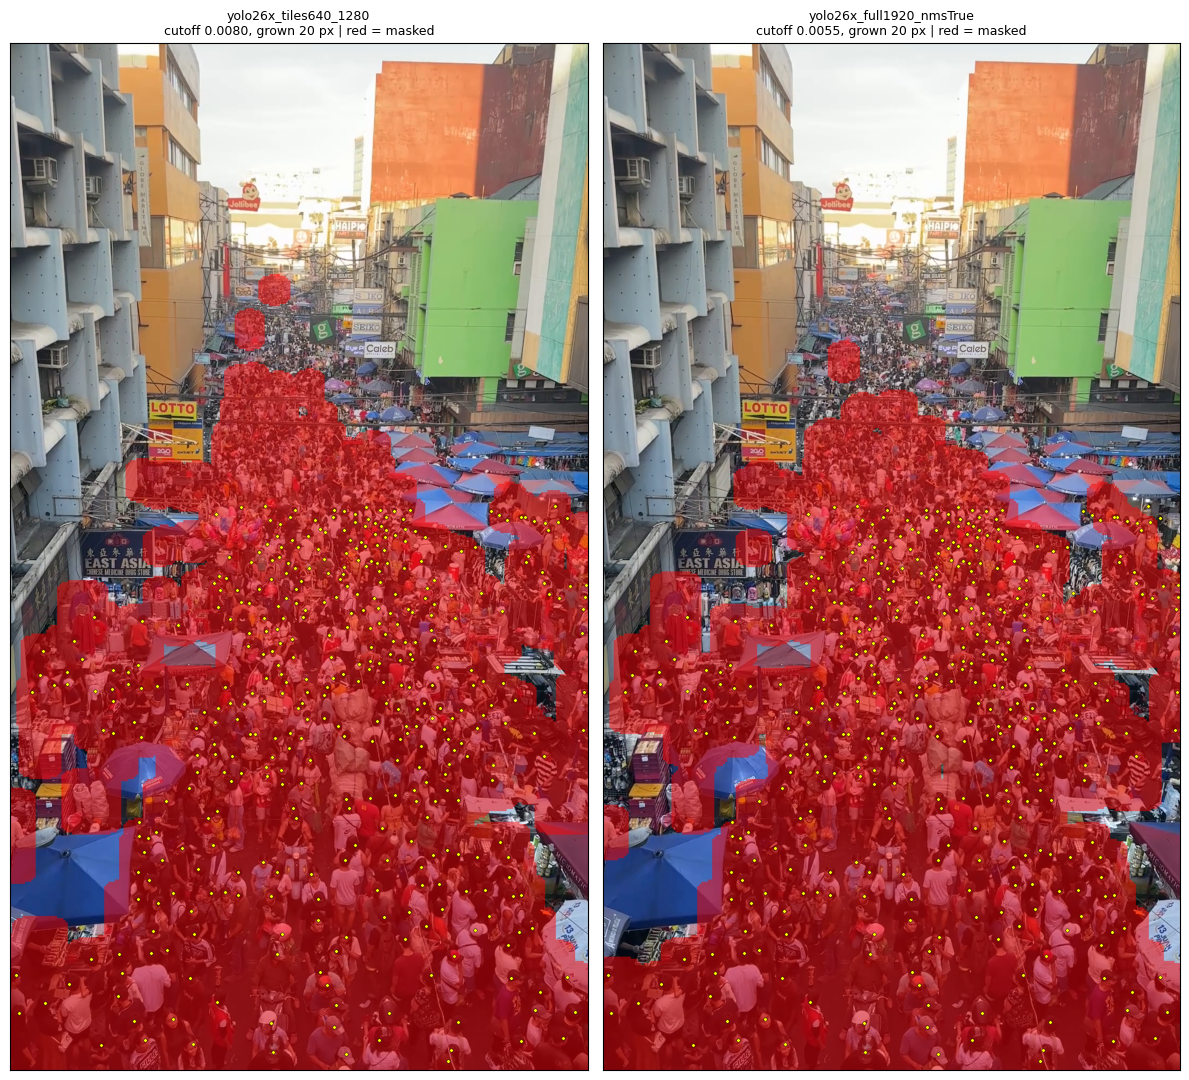

In [6]:
# ===== Cell 3b: overlay two masks on a labelled frame =====
import matplotlib.pyplot as plt

FRAME = 465
def read_frame(video, fid):
    """Read one frame (BGR) from the video by sequential decoding."""
    cap = cv2.VideoCapture(str(video)); i = 0
    while True:
        ok, img = cap.read()
        if not ok or i == fid:
            break
        i += 1
    cap.release()
    return img

img = cv2.cvtColor(read_frame(VIDEO, FRAME), cv2.COLOR_BGR2RGB)
gt = pts[pts.frame_id == FRAME][["x", "y"]].to_numpy(float)
fig, axs = plt.subplots(1, 2, figsize=(12, 11))
for ax, c in zip(axs, decisions["candidates"]):
    b, s = boxes_for(runs[c["source"]], FRAME)
    m = build_mask(b, s, c["cutoff"] * 0.5, (H, W), SC, 20)
    big = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)
    over = img.copy(); over[big > 0] = (0.5 * over[big > 0] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)
    ax.imshow(over); ax.scatter(gt[:, 0], gt[:, 1], s=6, c="yellow", edgecolors="black", linewidths=0.3)
    ax.set_title(f"{c['source']}\ncutoff {c['cutoff'] * 0.5:.4f}, grown 20 px | red = masked", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); fig.savefig(OUT5 / "E003b_mask_overlay.png", dpi=110); plt.show()

## Cell 4 – Camera-motion smoke test (v2)
. We check how much the camera moves in the first 120 frames (2 seconds). We only look at the background (buildings, signs) and ignore people, because people move on their own. Two things are new. First, we track corners with optical flow, which is precise to a fraction of a pixel; the old method could only see whole-pixel motion and missed slow camera drift. Second, we report the motion at the top, middle and bottom of the picture, so we can see whether a small rotation error would move the crowd area. Run this cell first (it only defines functions), then Cell 4b.

In [7]:
import time
from dataclasses import dataclass
from pathlib import Path
import cv2, numpy as np, pandas as pd


@dataclass(frozen=True)
class RegConfig:
    """Registration settings. Frames are matched at reduced size for speed; results are scaled back to full size.
    model:  'homography' (8 DOF), 'affine' (6 DOF) or 'similarity' (4 DOF: shift, rotation, one zoom).
    method: 'orb' (integer-pixel features) or 'lk' (sub-pixel Lucas-Kanade tracking)."""
    video: Path
    model: str = "homography"
    method: str = "orb"
    lk_win: int = 21
    scale: float = 0.5
    n_features: int = 4000
    ratio: float = 0.75
    thr_px: float = 3.0
    min_inliers: int = 60
    key_stride: int = 93


def frames_gray(video, scale, limit=None):
    """Yield (index, grayscale frame at matching resolution) one by one, optionally stopping after `limit` frames."""
    cap, i = cv2.VideoCapture(str(video)), 0
    while limit is None or i < limit:
        ok, f = cap.read()
        if not ok:
            break
        g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)                                   # colour is not needed for matching
        yield i, cv2.resize(g, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
        i += 1
    cap.release()


def fit_motion(a, b, cfg):
    """Robustly fit the chosen motion model mapping points a -> b. Always returns a 3x3 matrix (or None) and the
    inlier mask, so every model can be chained the same way. Rejects empty, wrong-shaped or non-finite results."""
    if cfg.model == "homography":
        M, inl = cv2.findHomography(a, b, cv2.USAC_MAGSAC, cfg.thr_px)
    else:
        fn = cv2.estimateAffinePartial2D if cfg.model == "similarity" else cv2.estimateAffine2D
        A, inl = fn(a, b, method=cv2.RANSAC, ransacReprojThreshold=cfg.thr_px, maxIters=4000, confidence=0.999)
        M = None if A is None else np.vstack([A, [0, 0, 1.0]])                    # lift 2x3 to 3x3
    if M is None or inl is None or np.shape(M) != (3, 3) or not np.all(np.isfinite(M)):
        return None, None
    return M, inl


def estimate_H(feat_src, feat_dst, cfg, matcher):
    """ORB path: match descriptors (ratio test) and fit motion src->dst. Returns (3x3 or None, n_inliers, ratio)."""
    (k1, d1), (k2, d2) = feat_src, feat_dst
    if d1 is None or d2 is None or len(k1) < 8 or len(k2) < 8:
        return None, 0, 0.0
    good = [m for m, n in (p for p in matcher.knnMatch(d1, d2, k=2) if len(p) == 2)
            if m.distance < cfg.ratio * n.distance]
    if len(good) < 8:
        return None, len(good), 0.0
    a = np.float32([k1[m.queryIdx].pt for m in good])
    b = np.float32([k2[m.trainIdx].pt for m in good])
    M, inl = fit_motion(a, b, cfg)
    if M is None:
        return None, 0, 0.0
    n_in = int(inl.sum())
    return M, n_in, n_in / len(good)


def to_full_res(H, scale):
    """Convert a transform estimated on scaled images to full-resolution pixel coordinates (pixel-centre aware)."""
    o = (scale - 1.0) / 2.0
    S = np.array([[scale, 0, o], [0, scale, o], [0, 0, 1.0]])
    return np.linalg.inv(S) @ H @ S


def lk_step(prev_gray, gray, prev_allowed, allowed, cfg):
    """LK path: pick corners on the previous frame's background, track them into this frame (sub-pixel accurate),
    drop lost points and points that land on the crowd, then fit motion current->previous.
    Returns (3x3 or None, n_inliers, inlier_ratio, n_points_used)."""
    p0 = cv2.goodFeaturesToTrack(prev_gray, cfg.n_features, 0.01, 7, mask=prev_allowed)
    if p0 is None or len(p0) < 8:
        return None, 0, 0.0, 0
    p1, st, _ = cv2.calcOpticalFlowPyrLK(prev_gray, gray, p0, None, winSize=(cfg.lk_win,) * 2, maxLevel=3)
    a, b = p0.reshape(-1, 2), p1.reshape(-1, 2)
    keep = st.ravel() == 1                                                        # tracking succeeded
    if allowed is not None:                                                       # ended up on a person -> drop
        xi = np.clip(np.round(b[:, 0]).astype(int), 0, gray.shape[1] - 1)
        yi = np.clip(np.round(b[:, 1]).astype(int), 0, gray.shape[0] - 1)
        keep &= allowed[yi, xi] > 0
    a, b = a[keep], b[keep]
    if len(a) < 8:
        return None, 0, 0.0, len(a)
    M, inl = fit_motion(b, a, cfg)                                                # current -> previous
    if M is None:
        return None, 0, 0.0, len(a)
    n_in = int(inl.sum())
    return M, n_in, n_in / len(a), len(a)


def register_video(cfg, allowed_fn=None, limit=None):
    """Chain frame-to-previous-frame transforms into G[t] (frame t -> frame 0). `allowed_fn(i)` returns a uint8 image
    (255 = features allowed) at matching resolution, or None = whole picture. On failure the last transform is held.
    Returns (G stack, per-frame table, keyframe ORB features for the drift check)."""
    orb = cv2.ORB_create(nfeatures=cfg.n_features)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    G, rows, prev, feats = [np.eye(3)], [], None, {}
    prev_gray = prev_allowed = None
    for i, gray in frames_gray(cfg.video, cfg.scale, limit):
        allowed = None if allowed_fn is None else allowed_fn(i)
        if cfg.method == "lk":                                                    # ---- sub-pixel path
            if prev_gray is None:
                rows.append(dict(frame=i, keypoints=0, inliers=np.nan, ratio=np.nan, ok=True))
            else:
                H, n_in, r, n_pts = lk_step(prev_gray, gray, prev_allowed, allowed, cfg)
                ok = H is not None and n_in >= cfg.min_inliers
                G.append(G[-1] @ to_full_res(H, cfg.scale) if ok else G[-1].copy())
                G[-1] /= G[-1][2, 2]
                rows.append(dict(frame=i, keypoints=n_pts, inliers=n_in, ratio=r, ok=ok))
            prev_gray, prev_allowed = gray, allowed
            continue
        feat = orb.detectAndCompute(gray, allowed)                                # ---- ORB path
        if cfg.key_stride and i % cfg.key_stride == 0:
            feats[i] = feat
        if prev is None:
            rows.append(dict(frame=i, keypoints=len(feat[0]), inliers=np.nan, ratio=np.nan, ok=True))
        else:
            H, n_in, r = estimate_H(feat, prev, cfg, matcher)
            ok = H is not None and n_in >= cfg.min_inliers
            G.append(G[-1] @ to_full_res(H, cfg.scale) if ok else G[-1].copy())
            G[-1] /= G[-1][2, 2]
            rows.append(dict(frame=i, keypoints=len(feat[0]), inliers=n_in, ratio=r, ok=ok))
        prev = feat
    return np.stack(G), pd.DataFrame(rows), feats


def shifts_at(G, shape_hw, fracs=(0.1, 0.5, 0.9)):
    """Distance (px) that the last transform moves points at 10% / 50% / 90% of the image height (x = W/2)."""
    h, w = shape_hw
    pts = np.float32([[[w / 2, f * h]] for f in fracs])
    out = cv2.perspectiveTransform(pts, G[-1].astype(np.float32))[:, 0] - pts[:, 0]
    return np.linalg.norm(out, axis=1)


def summarize_reg(G, rows, shape_hw, secs):
    """One-line summary: background features, inliers, failures, motion at top/centre/bottom, projective terms, speed."""
    top, mid, bot = shifts_at(G, shape_hw)
    return dict(median_keypoints=rows.keypoints.median(), median_inliers=rows.inliers.median(),
                min_inliers=rows.inliers.min(), failed_pairs=int((~rows.ok).sum()),
                shift_top_px=top, shift_centre_px=mid, shift_bottom_px=bot,
                bottom_minus_top_px=bot - top, proj_h31_h32=float(np.hypot(G[-1][2, 0], G[-1][2, 1])),
                s_per_frame=secs / len(rows))

## Cell 4b – Run the smoke test
We run 3 background settings (no mask, full-frame mask, tiled mask) × 3 methods (old ORB, new LK + similarity, new LK + homography) on 120 frames. What to read: (1) inliers should stay well above 60 for the masked runs; (2) the two masked runs should agree with each other and differ from "no mask"; (3) the new LK numbers should be larger than the old ORB numbers if the camera really drifts slowly; (4) bottom_minus_top_px near 0 means no rotation lever-arm problem. It takes a few minutes

In [8]:
def make_allowed_fn(run, cutoff, grow_px, scale, shape_hw):
    """Return f(i) -> uint8 image (255 = features allowed) at matching size: everything except the grown person
    boxes of frame i (detections with score >= cutoff)."""
    def allowed(i):
        boxes, scores = boxes_for(run, i)
        return ((1 - build_mask(boxes, scores, cutoff, shape_hw, scale, grow_px)) * 255).astype(np.uint8)
    return allowed


LIMIT = 120
SHAPE = (H, W)
MASKS = {
    "no mask": None,
    "full-frame mask (0.003, 20 px)": make_allowed_fn(runs["yolo26x_full1920_nmsTrue"], 0.003, 20, 0.5, SHAPE),
    "tiled mask (0.008, 20 px)": make_allowed_fn(runs["yolo26x_tiles640_1280"], 0.008, 20, 0.5, SHAPE),
}
METHODS = {                                       # name -> (tracker, motion model)
    "orb + homography (old)": ("orb", "homography"),
    "lk + similarity": ("lk", "similarity"),
    "lk + homography": ("lk", "homography"),
}

table = []
for mname, allowed_fn in MASKS.items():
    for tname, (method, model) in METHODS.items():
        cfg = RegConfig(video=VIDEO, method=method, model=model, key_stride=0)
        t0 = time.time()
        G, rows, _ = register_video(cfg, allowed_fn, limit=LIMIT)                 # register the first 120 frames
        secs = time.time() - t0
        table.append({"mask": mname, "tracker": tname, **summarize_reg(G, rows, SHAPE, secs)})
        print(f"done: {mname} | {tname} ({secs:.0f} s)")

df = pd.DataFrame(table)
df.to_csv(OUT5 / "E003b_smoke_test.csv", index=False)
pd.set_option("display.width", 250)
print(df.round(3).to_string(index=False))

done: no mask | orb + homography (old) (25 s)
done: no mask | lk + similarity (7 s)
done: no mask | lk + homography (7 s)
done: full-frame mask (0.003, 20 px) | orb + homography (old) (25 s)
done: full-frame mask (0.003, 20 px) | lk + similarity (5 s)
done: full-frame mask (0.003, 20 px) | lk + homography (5 s)
done: tiled mask (0.008, 20 px) | orb + homography (old) (22 s)
done: tiled mask (0.008, 20 px) | lk + similarity (5 s)
done: tiled mask (0.008, 20 px) | lk + homography (5 s)
                          mask                tracker  median_keypoints  median_inliers  min_inliers  failed_pairs  shift_top_px  shift_centre_px  shift_bottom_px  bottom_minus_top_px  proj_h31_h32  s_per_frame
                       no mask orb + homography (old)            4000.0          3569.0       3311.0             0         2.311            2.093         7.105000                4.794           0.0        0.212
                       no mask        lk + similarity            4000.0          4000.0  

# cell 5 Register the whole video and check for drift
We estimate the camera motion for all 1303 frames using optical flow and a perspective (homography) model, with the crowd masked out. We run three variations to see whether the answer changes: a looser matching threshold, similarity instead of homography, and the tiled mask instead of the full-frame mask. Then an independent check: every 93 frames we match the frame straight to the previous checkpoint frame (no chaining) and compare that with the chained answer. If they agree and the gap does not keep growing, there is no drift. The last line saves the frame → frame-0 transforms. It takes about 5 minutes. Cells 4 and 4b must have been run in this session first.


In [9]:
def direct_between_keys(cfg, key_ids, allowed_fn):
    """Independent drift check that survives big angle changes: register each keyframe straight to the PREVIOUS keyframe
    with ORB (no chaining), using only background visible in both. Returns {frame: (previous keyframe, 3x3 transform
    frame -> previous keyframe at full resolution)}."""
    orb = cv2.ORB_create(nfeatures=cfg.n_features)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    keys = sorted(key_ids)
    out, prev_i, prev_g = {}, None, None
    for i, gray in frames_gray(cfg.video, cfg.scale):
        if i in key_ids:
            if prev_i is not None:
                m0 = allowed_fn(prev_i) if allowed_fn else None
                mi = allowed_fn(i) if allowed_fn else None
                both = None if m0 is None else cv2.bitwise_and(m0, mi)            # background in BOTH frames
                M, n_in, _ = estimate_H(orb.detectAndCompute(gray, both), orb.detectAndCompute(prev_g, both), cfg, matcher)
                if M is not None and n_in >= cfg.min_inliers:
                    out[i] = (prev_i, to_full_res(M, cfg.scale))
            prev_i, prev_g = i, gray
        if i >= keys[-1]:
            break
    return out


def drift_table(G, direct, shape_hw, fracs=(0.1, 0.5, 0.9)):
    """For each keyframe pair: distance (px) between the chained motion G[prev]^-1 G[t] and the direct ORB motion,
    measured at the top/centre/bottom points. Small and not growing = the chain has no accumulated drift."""
    h, w = shape_hw
    pts = np.float32([[[w / 2, f * h]] for f in fracs])
    rows = []
    for t, (p, D) in sorted(direct.items()):
        chain = np.linalg.inv(G[p]) @ G[t]                                        # motion frame t -> frame p via the chain
        a = cv2.perspectiveTransform(pts, (chain / chain[2, 2]).astype(np.float32))
        b = cv2.perspectiveTransform(pts, (D / D[2, 2]).astype(np.float32))
        e = np.linalg.norm(a - b, axis=2).ravel()
        rows.append(dict(frame=t, vs_key=p, err_top=e[0], err_centre=e[1], err_bottom=e[2]))
    return pd.DataFrame(rows)


def track_points(G, shape_hw, fracs=(0.1, 0.5, 0.9)):
    """Where each frame's top/centre/bottom point lands in frame-0 coordinates: array (frames, 3, 2)."""
    h, w = shape_hw
    pts = np.float32([[[w / 2, f * h]] for f in fracs])
    return np.stack([cv2.perspectiveTransform(pts, g.astype(np.float32))[:, 0] for g in G])


# ---- settings -------------------------------------------------------------------------------------------------
SHAPE = (H, W)
FULL = make_allowed_fn(runs["yolo26x_full1920_nmsTrue"], 0.003, 20, 0.5, SHAPE)   # cheap mask (default)
TILED = make_allowed_fn(runs["yolo26x_tiles640_1280"], 0.008, 20, 0.5, SHAPE)     # expensive mask (cross-check)
RUNS = {                                          # name -> (mask, tracker, motion model, inlier threshold px)
    "A default: lk+homography, full mask, thr 1": (FULL, "lk", "homography", 1.0),
    "B similarity":                              (FULL, "lk", "similarity", 1.0),
    "C thr 3":                                   (FULL, "lk", "homography", 3.0),
    "D tiled mask":                              (TILED, "lk", "homography", 1.0),
}
A = "A default: lk+homography, full mask, thr 1"
LIMIT5 = None                                       # None = whole video

# ---- 1. register the whole video under each setting -------------------------------------------------------------
Gs, tab = {}, []
for name, (mask_fn, method, model, thr) in RUNS.items():
    cfg = RegConfig(video=VIDEO, method=method, model=model, thr_px=thr, key_stride=0)
    t0 = time.time()
    G, rows, _ = register_video(cfg, mask_fn, limit=LIMIT5)
    Gs[name] = G
    tab.append({"run": name, **summarize_reg(G, rows, SHAPE, time.time() - t0),
                "frames": len(G),
                "max_step_px": float(np.abs(np.diff(track_points(G, SHAPE), axis=0)).max())})   # biggest 1-frame jump
    rows.to_csv(OUT5 / f"E003b_rows_{name[0]}.csv", index=False)
    print(f"done {name}")
pd.set_option("display.width", 250)
print(pd.DataFrame(tab).round(3).to_string(index=False))

# ---- 2. how much do the runs disagree with the default (worst frame, top / centre / bottom point) ------------------
base = track_points(Gs[A], SHAPE)
for name, G in Gs.items():
    d = np.linalg.norm(track_points(G, SHAPE) - base, axis=2).max(axis=0)
    print(f"{name:45s} max |diff to A| top/centre/bottom: {d.round(2)}")

# ---- 3. independent drift check: chained motion vs direct ORB motion between consecutive keyframes ---------------
# ORB keypoints are whole-pixel, so this check uses a looser inlier threshold (3 px) than the sub-pixel LK chain (1 px).
cfgD = RegConfig(video=VIDEO, method="orb", model="homography", thr_px=3.0)
keys = set(range(0, len(Gs[A]), 93))
direct = direct_between_keys(cfgD, keys, FULL)
missing = sorted(k for k in keys if k != 0 and k not in direct)                   # keyframes where direct match failed
print("keyframes with no direct match (should be empty):", missing)
dt = drift_table(Gs[A], direct, SHAPE)
dt.to_csv(OUT5 / "E003b_drift_check.csv", index=False)
print(dt.round(2).to_string(index=False))

# ---- 4. save the default chain (frame t -> frame 0, full resolution) --------------------------------------------
np.save(OUT5 / "registration_G.npy", Gs[A])
print("saved", OUT5 / "registration_G.npy")

done A default: lk+homography, full mask, thr 1
done B similarity
done C thr 3
done D tiled mask
                                       run  median_keypoints  median_inliers  min_inliers  failed_pairs  shift_top_px  shift_centre_px  shift_bottom_px  bottom_minus_top_px  proj_h31_h32  s_per_frame  frames  max_step_px
A default: lk+homography, full mask, thr 1            1363.0          1362.5       1187.0             0    305.985992       230.703003       267.048004           -38.938000           0.0        0.040    1303        3.058
                              B similarity            1363.0          1362.5       1187.0             0    273.584991       246.054993       222.143997           -51.441002           0.0        0.039    1303        2.896
                                   C thr 3            1363.0          1362.5       1187.0             0    306.092987       230.667007       267.105011           -38.987999           0.0        0.039    1303        3.058
                   

## Cell 6 – Does the camera move explain the count drop?

We plot three things over time: how far the camera moved (top, middle and bottom of the picture), how big things look compared with frame 0 (a tilt makes the near street bigger and the far street smaller), and the number of people the detector finds. Then we print one line per second. If the camera starts tilting exactly when the count falls, that explains the ~15% drop we saw at 3–5 s. The "apparent size" numbers are also the first look at how much the pixels-per-metre scale changes during the video, which matters for calibration. It takes a few seconds. Cell 5 must have been run first.

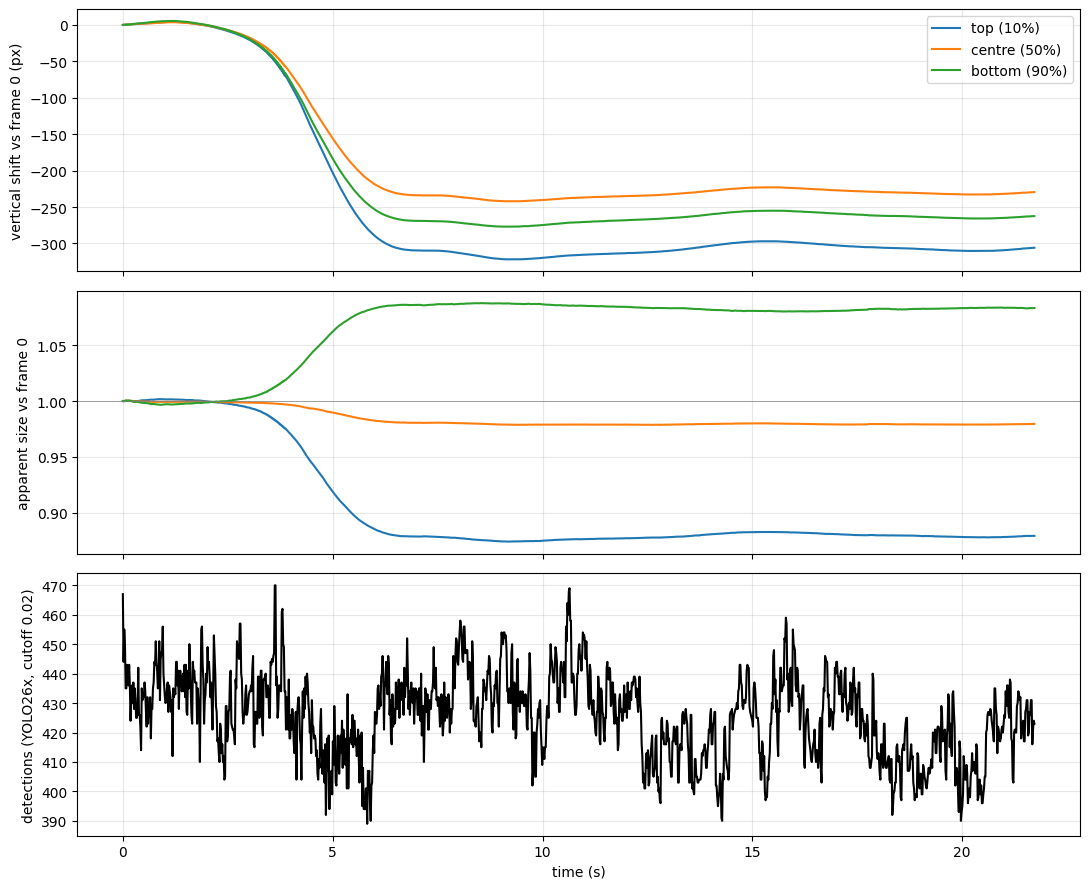

 sec  centre_shift_px  size_top  size_bottom  count
   0              0.0     1.000        1.000    467
   1              3.0     1.002        0.997    432
   2             -1.0     1.000        0.999    437
   3            -17.0     0.994        1.003    433
   4            -67.0     0.970        1.023    426
   5           -156.0     0.919        1.062    417
   6           -219.0     0.885        1.083    427
   7           -234.0     0.879        1.086    434
   8           -236.0     0.877        1.087    449
   9           -242.0     0.875        1.087    445
  10           -240.0     0.875        1.086    409
  11           -237.0     0.877        1.085    453
  12           -235.0     0.877        1.084    433
  13           -233.0     0.878        1.083    417
  14           -228.0     0.881        1.082    426
  15           -223.0     0.883        1.081    424
  16           -224.0     0.883        1.080    449
  17           -227.0     0.881        1.081    444
  18        

In [10]:
import matplotlib.pyplot as plt


def local_size_ratio(G, shape_hw, fracs=(0.1, 0.5, 0.9)):
    """How big things look in frame t compared with frame 0, at the top/centre/bottom points: 1/sqrt(|det J|) of the
    frame-t -> frame-0 transform G[t] (1.0 = same size, 1.2 = 20% bigger than in frame 0). Array (frames, 3)."""
    h, w = shape_hw
    pts = [(w / 2, f * h) for f in fracs]
    out = np.zeros((len(G), len(pts)))
    for t, g in enumerate(G):
        for j, (x, y) in enumerate(pts):
            d = g[2, 0] * x + g[2, 1] * y + g[2, 2]                                # projective denominator
            u = g[0, 0] * x + g[0, 1] * y + g[0, 2]                                # numerators of the mapped x and y
            v = g[1, 0] * x + g[1, 1] * y + g[1, 2]
            J = np.array([[g[0, 0] - g[2, 0] * u / d, g[0, 1] - g[2, 1] * u / d],  # local 2x2 Jacobian of the mapping
                          [g[1, 0] - g[2, 0] * v / d, g[1, 1] - g[2, 1] * v / d]]) / d
            out[t, j] = 1.0 / np.sqrt(abs(np.linalg.det(J)))
    return out


def counts_per_frame(run, cutoff, n_frames):
    """Number of detections above `cutoff` in every frame of one detector run."""
    return np.array([int((boxes_for(run, i)[1] >= cutoff).sum()) for i in range(n_frames)])


G = Gs[A]                                                   # default chain from Cell 5 (frame t -> frame 0)
n = len(G)
tp = track_points(G, SHAPE)                                 # (frames, 3, 2) in frame-0 coordinates
dy = tp[:, :, 1] - np.array([0.1 * H, 0.5 * H, 0.9 * H])    # vertical camera motion at top / centre / bottom
size = local_size_ratio(G, SHAPE)                           # apparent size vs frame 0
cnt = counts_per_frame(runs["yolo26x_full1920_nmsTrue"], 0.02, n)   # E003 F1-optimal cutoff for this detector
sec = np.arange(n) / FPS

fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for j, lab in enumerate(["top (10%)", "centre (50%)", "bottom (90%)"]):
    ax[0].plot(sec, dy[:, j], label=lab)
    ax[1].plot(sec, size[:, j], label=lab)
ax[0].set_ylabel("vertical shift vs frame 0 (px)"); ax[0].legend()
ax[1].set_ylabel("apparent size vs frame 0"); ax[1].axhline(1, color="grey", lw=0.5)
ax[2].plot(sec, cnt, color="k"); ax[2].set_ylabel("detections (YOLO26x, cutoff 0.02)"); ax[2].set_xlabel("time (s)")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(OUT5 / "E003b_camera_vs_counts.png", dpi=110); plt.show()

# one line per second: camera position, apparent size, and count
per_sec = pd.DataFrame({"sec": np.arange(int(sec[-1]) + 1)})
idx = (per_sec.sec * FPS).round().astype(int).clip(upper=n - 1)
per_sec["centre_shift_px"] = dy[idx, 1].round(0)
per_sec["size_top"] = size[idx, 0].round(3)
per_sec["size_bottom"] = size[idx, 2].round(3)
per_sec["count"] = cnt[idx]
print(per_sec.to_string(index=False))
per_sec.to_csv(OUT5 / "E003b_camera_vs_counts.csv", index=False)

In [11]:
import shutil
from pathlib import Path


def pack_folder(folder, zip_stem):
    """Zip every file in `folder` into /kaggle/working/<zip_stem>.zip and list what went in, with sizes."""
    folder = Path(folder)
    files = sorted(p for p in folder.iterdir() if p.is_file())
    for p in files:
        print(f"{p.name:35s} {p.stat().st_size / 1024:8.1f} KB")
    zip_path = shutil.make_archive(f"/kaggle/working/{zip_stem}", "zip", root_dir=folder)
    print(f"\ncreated {zip_path}: {Path(zip_path).stat().st_size / 1024:.0f} KB, {len(files)} files")
    return zip_path


pack_folder(OUT5, "e003b_registration")

E003b_camera_vs_counts.csv               0.6 KB
E003b_camera_vs_counts.png             154.4 KB
E003b_drift_check.csv                    0.6 KB
E003b_mask_candidates.csv                1.1 KB
E003b_mask_overlay.png                1476.8 KB
E003b_rows_A.csv                        33.6 KB
E003b_rows_B.csv                        33.7 KB
E003b_rows_C.csv                        32.9 KB
E003b_rows_D.csv                        33.5 KB
E003b_smoke_test.csv                     1.4 KB
registration_G.npy                      91.7 KB

created /kaggle/working/e003b_registration.zip: 1720 KB, 11 files


'/kaggle/working/e003b_registration.zip'